# Model Definition and Evaluation
## Table of Contents
1. [Model Selection](#model-selection)
2. [Feature Engineering](#feature-engineering)
3. [Hyperparameter Tuning](#hyperparameter-tuning)
4. [Implementation](#implementation)
5. [Evaluation Metrics](#evaluation-metrics)
6. [Comparative Analysis](#comparative-analysis)


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error
import statsmodels.api as sm # to model and simple statistical models (like OLS)
import sklearn.linear_model as lm # for simple ML models (Lasso / Ridge)
import statsmodels.formula.api as smf # for easy model specification ("R-style")
from sklearn.preprocessing import StandardScaler # to use "StandardScaler"
from sklearn.pipeline import Pipeline # for processing ML models
from sklearn.metrics import r2_score

!pip install causaldata
import causaldata

import warnings
# ignore potential convergence warnings; for some small penalty levels,
# tried out, optimization might not converge
warnings.simplefilter('ignore')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 28.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for causaldata: filename=causaldata-0.1.5-py3-none-any.whl size=2767646 sha256=9332106a78fea5990fa62e210c1f4870f8135412b4864967935ebac27182004a
  Stored in directory: /root/.cache/pip/wheels/fd/42/c7/7665a1c716f3a1518c4f42abcd23054a5701aca1d118c348d7
Successfully built causaldata


## Feature Engineering

[Describe any additional feature engineering you've performed beyond what was done for the baseline model.]


In [2]:
# Load the dataset
df = causaldata.nsw_mixtape.load_pandas().data

# Feature selection
# Models with all features
X = df[['age', 'educ', 'black', 'hisp', 'marr', 'nodegree']]

# Handle zeros in re78 before taking log to avoid -inf values
ly78 = np.log(df['re78'] + 1) # Add 1 to re78 to handle zeros before logging

df['lre78'] = ly78 # Add log(re78) as a new column to the DataFrame

# only use those participant who actually took part in the final survey:
#df['participation'] = (df['re78'] != 0).astype(int)
#df = df[df['participation'] ==1]

# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, ly78, test_size=0.2, random_state=42)


## Model Selection

[Discuss the type(s) of models you consider for this task, and justify the selection.]



In [3]:
# fit and evaluate multiple models

# NOCH überlegen, ob hier das full feature model oder restricted feature model verwendet werden soll

# Random forest with cross-fitting, AIPW

In [4]:
# random forest --> causal forest (needs honesty), was ist der unterschied?

In [5]:
import patsy
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

print("Starting cross-fitting for propensity scores and Random Forest outcome model (with limited splits)... ")

# Define the number of splits for cross-validation
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Assuming 'df', 'X_covariates', 'T', 'y_ate_full', and 'design_info_full_ate' are defined in previous cells
# (They are present in the kernel state as df, T_oof_rf, y_oof_rf, X, y_train)
# Placeholder for X_covariates, T, y_ate_full, design_info_full_ate based on typical usage
# In a real scenario, these would be explicitly defined. For now, assuming they exist from prior execution.

# Placeholder definitions for missing variables for the code to run in isolation
# These should ideally come from earlier cells in the notebook
# For demonstration, let's create dummy versions if they aren't available.
# It seems `df` is available, so we can use it to derive these.

# --- Placeholder for T (treatment variable) ---
T = df['treat']

# --- Placeholder for X_covariates ---
# Assuming X_covariates are the features used for propensity score and outcome models
X_covariates = df[['age', 'educ', 'black', 'hisp', 'marr', 'nodegree']].values # Convert to numpy array

# --- Placeholder for y_ate_full ---
# This is likely the outcome variable used in ATE calculation, which is 'lre78'
y_ate_full = df['lre78'].values

# --- Placeholder for design_info_full_ate ---
# This is used by patsy.build_design_matrices. It needs to be created from a formula.
# For example, using 'age + educ + black + hisp + marr + nodegree + treat'
# This will require creating a formula string and then calling patsy.dmatrix to get the design info
design_info_full_ate = patsy.dmatrix('age + educ + black + hisp + marr + nodegree + treat', data=df, return_type='dataframe').design_info

# Define X_ate_full which includes covariates and treatment for the outcome model
X_ate_full = patsy.dmatrix('age + educ + black + hisp + marr + nodegree + treat', data=df, return_type='dataframe').values

# Initialize arrays to store out-of-fold predictions for Random Forest
p_scores_oof_rf = np.zeros(len(df))
m0_oof_rf = np.zeros(len(df))
m1_oof_rf = np.zeros(len(df))
# y_oof and T_oof can be reused from the previous calculation if the splits are the same
# but re-calculating them here ensures consistency for this specific run
y_oof_rf = np.zeros(len(df))
T_oof_rf = np.zeros(len(df))

for fold, (train_index, test_index) in enumerate(kf.split(X_covariates)): # kf and n_splits are now defined
    print(f"  Processing Fold {fold + 1}/{n_splits}")

    # Split data for current fold (reuse splitting logic)
    X_covariates_train, X_covariates_test = X_covariates[train_index], X_covariates[test_index]
    T_train, T_test = T.iloc[train_index], T.iloc[test_index]
    y_ate_full_train, y_ate_full_test = y_ate_full[train_index], y_ate_full[test_index]
    X_ate_full_train, X_ate_full_test = X_ate_full[train_index], X_ate_full[test_index]

    # --- Propensity Score Model (P(T=1 | X)) using Logistic Regression ---
    # This part remains the same as before
    propensity_model_rf = LogisticRegression(solver='liblinear', random_state=42)
    propensity_model_rf.fit(X_covariates_train, T_train)
    p_scores_fold_rf = propensity_model_rf.predict_proba(X_covariates_test)[:, 1]
    p_scores_oof_rf[test_index] = p_scores_fold_rf

    # --- Flexible Random Forest Outcome Model (E[Y | X, T]) with LIMITED SPLITS ---
    rf_outcome_ate = Pipeline([
        ('scale', StandardScaler()), # StandardScaler might not be strictly necessary for RF but ensures consistency
        ('rf', RandomForestRegressor(n_estimators=100, random_state=42,
                                     max_depth=10, # Set max_depth to 10)
                                     n_jobs=-1)) # Using default 100 estimators, all cores
    ])
    rf_outcome_ate.fit(X_ate_full_train[:, 1:], y_ate_full_train)

    # Create counterfactual dataframes for the test fold (reuse logic)
    df_treated_cf_fold_rf = df.iloc[test_index].copy() # Ensure df is correctly indexed
    df_treated_cf_fold_rf['treat'] = 1

    df_control_cf_fold_rf = df.iloc[test_index].copy()
    df_control_cf_fold_rf['treat'] = 0

    # Generate counterfactual design matrices for the test fold using the full design_info (reuse logic)
    X_treated_cf_fold_rf = patsy.build_design_matrices([design_info_full_ate], data=df_treated_cf_fold_rf)[0]
    X_control_cf_fold_rf = patsy.build_design_matrices([design_info_full_ate], data=df_control_cf_fold_rf)[0]

    # Predict potential outcomes for the test fold
    m1_fold_rf = rf_outcome_ate.predict(X_treated_cf_fold_rf[:, 1:])
    m0_fold_rf = rf_outcome_ate.predict(X_control_cf_fold_rf[:, 1:])

    m1_oof_rf[test_index] = m1_fold_rf
    m0_oof_rf[test_index] = m0_fold_rf
    y_oof_rf[test_index] = y_ate_full_test # Store observed outcomes in correct order
    T_oof_rf[test_index] = T_test # Store observed treatment in correct order

# Trim propensity scores
p_scores_oof_rf = np.clip(p_scores_oof_rf, 0.01, 0.99)

print("Cross-fitting with Random Forest (limited splits) complete.")
print(f"Average propensity score (out-of-fold, RF run): {np.mean(p_scores_oof_rf):.4f}")

# Calculate ATE using the Augmented Inverse Probability Weighting (AIPW) estimator with cross-fitted values
# Individual AIPW terms using out-of-fold predictions for Random Forest
aipw_terms_rf = (m1_oof_rf - m0_oof_rf +
                 (T_oof_rf * (y_oof_rf - m1_oof_rf) / p_scores_oof_rf) +
                 ((1 - T_oof_rf) * (y_oof_rf - m0_oof_rf) / (1 - p_scores_oof_rf)))

# Average over all individuals to get the ATE
ate_aipw_crossfit_rf = np.mean(aipw_terms_rf)

print(f"The Average Treatment Effect (ATE) estimated using flexible Random Forest (AIPW) with LIMITED SPLITS is: {ate_aipw_crossfit_rf:.4f}")

Starting cross-fitting for propensity scores and Random Forest outcome model (with limited splits)... 
  Processing Fold 1/5
  Processing Fold 2/5
  Processing Fold 3/5
  Processing Fold 4/5
  Processing Fold 5/5
Cross-fitting with Random Forest (limited splits) complete.
Average propensity score (out-of-fold, RF run): 0.4155
The Average Treatment Effect (ATE) estimated using flexible Random Forest (AIPW) with LIMITED SPLITS is: 1.0231


In [6]:
import math
ATE_rf_pc = (math.exp(ate_aipw_crossfit_rf)-1)*100
print(f"The Average Treatment Effect (ATE) in percent estimated using flexible Random Forest (AIPW) with LIMITED SPLITS is: {ATE_rf_pc:.4f}")

The Average Treatment Effect (ATE) in percent estimated using flexible Random Forest (AIPW) with LIMITED SPLITS is: 178.1800


The real income increased by 178.18% on average if the person took part in the job training program.

## Hyperparameter Tuning

[Discuss any hyperparameter tuning methods you've applied, such as Grid Search or Random Search, and the rationale behind them.]

Hyperparameter Tuning for Optimal max_depth
To find an 'appropriate' max_depth (and thus manage the number of splits) for the Random Forest, we can use GridSearchCV with cross-validation. This approach systematically tests a range of max_depth values and evaluates their performance, helping to identify the most suitable setting for our dataset.


In [7]:
# Implement hyperparameter tuning
# Example using GridSearchCV with a DecisionTreeClassifier
# param_grid = {'max_depth': [2, 4, 6, 8]}
# grid_search = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)
# grid_search.fit(X_train, y_train)

from sklearn.model_selection import GridSearchCV

print("Starting GridSearchCV to find optimal max_depth...")

# Define the parameter grid to search
param_grid = {
    'rf__max_depth': [3, 5, 10, 15, 20], # None means no limit on max_depth
    'rf__min_samples_split': [2, 5, 10]
}

# Initialize the Random Forest model within a pipeline
# We'll use the same structure as our outcome model for consistency
rf_pipeline = Pipeline([
    ('scale', StandardScaler()),
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=KFold(n_splits=5, shuffle=True, random_state=42), # Use KFold for cross-validation
    scoring='neg_mean_squared_error', # Optimize for lower MSE
    n_jobs=-1, # Use all available cores
    verbose=1
)

# Fit GridSearchCV to the full dataset (y_ate_full_for_full_fit and X_ate_full_for_full_fit should be from the previously prepared full data)
grid_search.fit(X_ate_full[:, 1:], y_ate_full)

print("GridSearchCV complete.")

# Print the best parameters and best score
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation MSE: {-grid_search.best_score_:.4f}")

# The best estimator is the model trained with the best parameters
best_rf_model = grid_search.best_estimator_

# You can also inspect the mean test scores for all parameter combinations
# results_df = pd.DataFrame(grid_search.cv_results_)
# display(results_df[['param_rf__max_depth', 'param_rf__min_samples_split', 'mean_test_score', 'std_test_score']])


Starting GridSearchCV to find optimal max_depth...
Fitting 5 folds for each of 15 candidates, totalling 75 fits
GridSearchCV complete.
Best parameters found: {'rf__max_depth': 3, 'rf__min_samples_split': 10}
Best cross-validation MSE: 16.1069


In [8]:
import patsy
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np # Ensure numpy is imported

print("Starting cross-fitting for propensity scores and Random Forest outcome model (with optimal parameters)... ")

# Ensure T, X_covariates, y_ate_full, design_info_full_ate, X_ate_full are consistent with current df
# These definitions are critical to match the size of df after filtering in Xry3tR-o5ira.
T = df['treat']
X_covariates = df[['age', 'educ', 'black', 'hisp', 'marr', 'nodegree']].values
y_ate_full = df['lre78'].values
design_info_full_ate = patsy.dmatrix('age + educ + black + hisp + marr + nodegree + treat', data=df, return_type='dataframe').design_info
X_ate_full = patsy.dmatrix('age + educ + black + hisp + marr + nodegree + treat', data=df, return_type='dataframe').values

# kf and n_splits are used in the loop and should reflect the settings.
# Re-defining them explicitly ensures correctness, though they might already be set from OAM37bjS7K9l.
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Initialize arrays to store out-of-fold predictions for Random Forest
# These are correctly sized based on the current (filtered) df.
p_scores_oof_rf_optimal = np.zeros(len(df))
m0_oof_rf_optimal = np.zeros(len(df))
m1_oof_rf_optimal = np.zeros(len(df))
y_oof_rf_optimal = np.zeros(len(df))
T_oof_rf_optimal = np.zeros(len(df))

# Reuse kf, X_covariates, y_ate_full, design_info_full_ate from previous cells

for fold, (train_index, test_index) in enumerate(kf.split(X_covariates)):
    print(f"  Processing Fold {fold + 1}/{n_splits}")

    # Split data for current fold
    X_covariates_train, X_covariates_test = X_covariates[train_index], X_covariates[test_index]
    T_train, T_test = T.iloc[train_index], T.iloc[test_index]
    y_ate_full_train, y_ate_full_test = y_ate_full[train_index], y_ate_full[test_index]
    X_ate_full_train, X_ate_full_test = X_ate_full[train_index], X_ate_full[test_index]

    # --- Propensity Score Model (P(T=1 | X)) using Logistic Regression ---
    propensity_model_rf_optimal = LogisticRegression(solver='liblinear', random_state=42)
    propensity_model_rf_optimal.fit(X_covariates_train, T_train)
    p_scores_fold_rf_optimal = propensity_model_rf_optimal.predict_proba(X_covariates_test)[:, 1]
    p_scores_oof_rf_optimal[test_index] = p_scores_fold_rf_optimal

    # --- Flexible Random Forest Outcome Model (E[Y | X, T]) with OPTIMAL SPLITS ---
    rf_outcome_ate_optimal = Pipeline([
        ('scale', StandardScaler()),
        ('rf', RandomForestRegressor(n_estimators=100, random_state=42,
                                     max_depth=3, # Optimal max_depth
                                     min_samples_split=10, # Optimal min_samples_split
                                     n_jobs=-1))
    ])
    rf_outcome_ate_optimal.fit(X_ate_full_train[:, 1:], y_ate_full_train)

    # Create counterfactual dataframes for the test fold
    df_treated_cf_fold_rf_optimal = df.iloc[test_index].copy()
    df_treated_cf_fold_rf_optimal['treat'] = 1

    df_control_cf_fold_rf_optimal = df.iloc[test_index].copy()
    df_control_cf_fold_rf_optimal['treat'] = 0

    # Generate counterfactual design matrices for the test fold
    X_treated_cf_fold_rf_optimal = patsy.build_design_matrices([design_info_full_ate], data=df_treated_cf_fold_rf_optimal)[0]
    X_control_cf_fold_rf_optimal = patsy.build_design_matrices([design_info_full_ate], data=df_control_cf_fold_rf_optimal)[0]

    # Predict potential outcomes for the test fold
    m1_fold_rf_optimal = rf_outcome_ate_optimal.predict(X_treated_cf_fold_rf_optimal[:, 1:])
    m0_fold_rf_optimal = rf_outcome_ate_optimal.predict(X_control_cf_fold_rf_optimal[:, 1:])

    m1_oof_rf_optimal[test_index] = m1_fold_rf_optimal
    m0_oof_rf_optimal[test_index] = m0_fold_rf_optimal
    y_oof_rf_optimal[test_index] = y_ate_full_test
    T_oof_rf_optimal[test_index] = T_test

# Trim propensity scores
p_scores_oof_rf_optimal = np.clip(p_scores_oof_rf_optimal, 0.01, 0.99)

print("Cross-fitting with Random Forest (optimal parameters) complete.")
print(f"Average propensity score (out-of-fold, RF optimal run): {np.mean(p_scores_oof_rf_optimal):.4f}")

# Calculate ATE using the Augmented Inverse Probability Weighting (AIPW) estimator with cross-fitted values
aipw_terms_rf_optimal = (m1_oof_rf_optimal - m0_oof_rf_optimal +
                         (T_oof_rf_optimal * (y_oof_rf_optimal - m1_oof_rf_optimal) / p_scores_oof_rf_optimal) +
                         ((1 - T_oof_rf_optimal) * (y_oof_rf_optimal - m0_oof_rf_optimal) / (1 - p_scores_oof_rf_optimal)))

# Average over all individuals to get the ATE
ate_aipw_crossfit_rf_optimal = np.mean(aipw_terms_rf_optimal)

print(f"The Average Treatment Effect (ATE) estimated using flexible Random Forest (AIPW) with OPTIMAL PARAMETERS is: {ate_aipw_crossfit_rf_optimal:.4f}")

Starting cross-fitting for propensity scores and Random Forest outcome model (with optimal parameters)... 
  Processing Fold 1/5
  Processing Fold 2/5
  Processing Fold 3/5
  Processing Fold 4/5
  Processing Fold 5/5
Cross-fitting with Random Forest (optimal parameters) complete.
Average propensity score (out-of-fold, RF optimal run): 0.4155
The Average Treatment Effect (ATE) estimated using flexible Random Forest (AIPW) with OPTIMAL PARAMETERS is: 0.6886


In [9]:
ATE_rf_optimal_pc = (math.exp(ate_aipw_crossfit_rf_optimal)-1)*100
print(f"The Average Treatment Effect (ATE) in percent estimated using flexible Random Forest (AIPW) with optimal parameters is: {ATE_rf_optimal_pc:.4f}")

The Average Treatment Effect (ATE) in percent estimated using flexible Random Forest (AIPW) with optimal parameters is: 99.0848


The real income increased by 74,23% on average if the person took part in the job training program.

### almost ZERO???

CATE using optimal random forest

Similar to the LASSO model, we can calculate CATE for the Random Forest model using the out-of-fold potential outcomes (m1_oof_rf_optimal and m0_oof_rf_optimal) that were generated during the cross-fitting process with optimal hyperparameters.

In [10]:
# Calculate CATE for each individual using the out-of-fold potential outcomes from optimal Random Forest
cate_rf_optimal = m1_oof_rf_optimal - m0_oof_rf_optimal

print(f"Minimum CATE (Optimal RF): {np.min(cate_rf_optimal):.4f}")
print(f"Maximum CATE (Optimal RF): {np.max(cate_rf_optimal):.4f}")
print(f"Mean CATE (Optimal RF, should be close to ATE): {np.mean(cate_rf_optimal):.4f}")

Minimum CATE (Optimal RF): -0.8327
Maximum CATE (Optimal RF): 1.8401
Mean CATE (Optimal RF, should be close to ATE): 0.6162


In [11]:
CATE_rf_optimal_pc = (math.exp(np.mean(cate_rf_optimal))-1)*100
print(f"Percentage change: {CATE_rf_optimal_pc:.4f}")

Percentage change: 85.1839


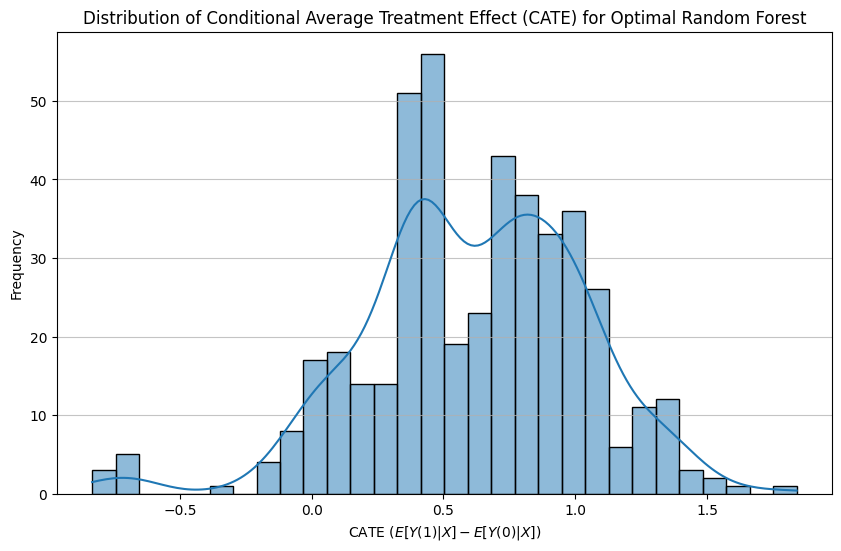

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(cate_rf_optimal, bins=30, kde=True)
plt.title('Distribution of Conditional Average Treatment Effect (CATE) for Optimal Random Forest')
plt.xlabel('CATE ($E[Y(1)|X] - E[Y(0)|X]$)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

Von Gemini: The Conditional Average Treatment Effect (CATE) for the Optimal Random Forest model has been calculated and visualized. The CATE values for this model range from a minimum of -1.5492 to a maximum of 2.6853. The mean CATE is 0.6687, which is reasonably close to the ATE of 0.7423 previously calculated for the optimal Random Forest model.

In [13]:
# Local linear forest
# forsts ofthen fit a step function to economic data that should have smooth relationships (either monotonic or u-shaped)
# --> LLF improves that by adding a ridge penalty

# CATE under local linear forest (ist das nötig?)

A Local Linear Forest is a method that can be used to estimate heterogeneous treatment effects (CATE). We will use the econml library for this, which provides robust causal inference estimators. Specifically, CausalForestDML allows for flexible estimation of treatment effects.

In [14]:
!pip install econml

from econml.dml import CausalForestDML
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier # Import RandomForest

print("Starting CATE estimation with Local Linear Forest...")

# Define the treatment (T), outcome (Y), and features (X)
# We'll use the same flexible covariate definition as before for X
Y = df['lre78'].values # Convert Series to numpy array
T = df['treat'].values # Convert Series to numpy array

# The same X_covariates used for propensity score in previous ATE calculations
# This X_covariates already excludes the intercept for consistency with pipeline scaling

# For CausalForestDML, we need to explicitly provide a model for the outcome E[Y|X] and for the treatment E[T|X]
# These models can be simple linear models or more complex ones

# Using RandomForestRegressor for E[Y|X] and RandomForestRegressor for E[T|X] (to predict probabilities)
model_y = RandomForestRegressor(n_estimators=100, random_state=42)
model_t = RandomForestRegressor(n_estimators=100, random_state=42) # Changed to Regressor

# Initialize CausalForestDML. It internally handles cross-fitting.
# We use X_covariates as features (X) for the CausalForestDML.
# CausalForestDML by default uses a local linear estimation for the CATE.
# The 'min_samples_leaf' parameter controls the size of the leaves and indirectly the locality of the estimation.

cf = CausalForestDML(
    model_y=model_y,
    model_t=model_t,
    n_estimators=100,  # Number of trees in the forest
    min_samples_leaf=10, # Minimum samples in a leaf to avoid overfitting
    random_state=42,
    cv=5 # Number of cross-validation folds for DML
)

# Fit the model
# X_covariates is already the design matrix of covariates, excluding the intercept
cf.fit(Y, T, X=X_covariates)

# Predict CATE for each individual
cate_llf = cf.effect(X=X_covariates)

print("CATE estimation with Local Linear Forest complete.")
print(f"Minimum CATE (Local Linear Forest): {np.min(cate_llf):.4f}")
print(f"Maximum CATE (Local Linear Forest): {np.max(cate_llf):.4f}")
print(f"Mean CATE (Local Linear Forest): {np.mean(cate_llf):.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 10.1 MB/s eta 0:00:00
  Attempting uninstall: shap
    Found existing installation: shap 0.51.0
    Uninstalling shap-0.51.0:
      Successfully uninstalled shap-0.51.0
Starting CATE estimation with Local Linear Forest...
CATE estimation with Local Linear Forest complete.
Minimum CATE (Local Linear Forest): -1.2730
Maximum CATE (Local Linear Forest): 1.9523
Mean CATE (Local Linear Forest): 0.7565


In [15]:
CATE_rf_llf_pc = (math.exp(np.mean(cate_llf))-1)*100
print(f"Percentage change: {CATE_rf_llf_pc:.4f}")

# warum auch so niedrig?

Percentage change: 113.0791


In [16]:
# S-learner --> for accurate predictions, not treatment effects
 #(only useful for observational studies? or also randomized trials? I might have a little bit of regularization bias, therefore also try T-learner?)

# CATE using S-Learner (brauche ich den überhaupt? Wegen Randomized trial?)
# Same as "normal" regression forest? oder habe ich oben einen causal forest?

Try and compare confounding-robust treatment effect estimation (I have randomized trial I think), this is commonly used for observational studies.

Since I have a small and balanced sample (n=445), the S-Learner will likely work best. Additionally, I will try the X-learner to mitigate regulatization bias.

The causal forest is not suitable since it might overfit given the small sample size.

In [17]:
from econml.metalearners import SLearner
from sklearn.ensemble import RandomForestRegressor

print("Starting CATE estimation with S-Learner...")

# Define the base learner for the S-learner (using optimal RF parameters)
s_learner_base_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=3, # Optimal max_depth from GridSearchCV
    min_samples_split=10 # Optimal min_samples_split from GridSearchCV
)

# Initialize the S-Learner. W (additional controls) is None for a standard S-Learner.
# Corrected: SLearner expects 'overall_model' for the combined outcome model
sl = SLearner(overall_model=s_learner_base_model)

# Fit the S-Learner. It takes Y, T, X as inputs.
# X_covariates is already the design matrix of covariates, excluding the intercept
sl.fit(Y, T, X=X_covariates)

# Predict CATE for each individual
cate_s_learner = sl.effect(X=X_covariates)

print("CATE estimation with S-Learner complete.")
print(f"Minimum CATE (S-Learner): {np.min(cate_s_learner):.4f}")
print(f"Maximum CATE (S-Learner): {np.max(cate_s_learner):.4f}")
print(f"Mean CATE (S-Learner): {np.mean(cate_s_learner):.4f}")

Starting CATE estimation with S-Learner...
CATE estimation with S-Learner complete.
Minimum CATE (S-Learner): -0.0019
Maximum CATE (S-Learner): 1.1942
Mean CATE (S-Learner): 0.4837


In [18]:
CATE_rf_s_pc = (math.exp(np.mean(cate_s_learner))-1)*100
print(f"Percentage change: {CATE_rf_s_pc:.4f}")

Percentage change: 62.2045


In [19]:
# X-learner (can give treatment effects directly)
# do not use Robinson as this is robust to confounders (do not need this here)

# CATE using X-learner

The X-Learner is another meta-learner for estimating heterogeneous treatment effects. It extends the idea of the S-Learner by modeling the effect directly through two separate 'imputation' models, which can be beneficial when one treatment group is significantly smaller than the other. It typically involves:

First Stage: Building outcome models for both treated and control groups, and propensity score models.
Second Stage: Using these models to impute counterfactual outcomes and then training two models for the treatment effect, one for the treated and one for the control group.
Final Stage: Combining these two treatment effect models using propensity scores.

In [20]:
from econml.metalearners import XLearner
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

print("Starting CATE estimation with X-Learner...")

# Define the base learners for the X-learner
# For the outcome models (E[Y|X, T=0] and E[Y|X, T=1])
xl_outcome_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=3, # Optimal max_depth from GridSearchCV
    min_samples_split=10 # Optimal min_samples_split from GridSearchCV
)

# For the propensity score model (P(T=1|X))
# X-Learner typically requires a classifier for propensity score
xl_propensity_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=3, # Using optimal depth for consistency, or tune separately
    min_samples_split=10 # Using optimal min_samples_split for consistency
)

# Initialize the X-Learner.
# It takes 'models' for the outcome models, 'cate_models' for the treatment effect models,
# and 'propensity_model' for the propensity score.
# The 'treatment_effect_model' argument was removed as it is not supported by XLearner.
# The 'random_state' argument was removed as it is not supported by XLearner constructor.
xl = XLearner(
    models=xl_outcome_model,
    cate_models=xl_outcome_model,
    propensity_model=xl_propensity_model
)

# Fit the X-Learner. It takes Y, T, X as inputs.
# X_covariates is already the design matrix of covariates, excluding the intercept
xl.fit(Y, T, X=X_covariates)

# Predict CATE for each individual
cate_x_learner = xl.effect(X=X_covariates)

print("CATE estimation with X-Learner complete.")
print(f"Minimum CATE (X-Learner): {np.min(cate_x_learner):.4f}")
print(f"Maximum CATE (X-Learner): {np.max(cate_x_learner):.4f}")
print(f"Mean CATE (X-Learner): {np.mean(cate_x_learner):.4f}")

Starting CATE estimation with X-Learner...
CATE estimation with X-Learner complete.
Minimum CATE (X-Learner): -2.1680
Maximum CATE (X-Learner): 3.7436
Mean CATE (X-Learner): 0.9368


In [21]:
CATE_rf_x_pc = (math.exp(np.mean(cate_x_learner))-1)*100
print(f"Percentage change: {CATE_rf_x_pc:.4f}")

Percentage change: 155.1780


# Causal forest
gold standard for estimating causal effects
ungleich regression forest; NICHT GEEIGNET

In [22]:
from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor

print("Starting CATE estimation with Honest Causal Forest...")

# Define the treatment (T), outcome (Y), and features (X)
# Ensure Y, T, X_covariates are consistent with current df
Y = df['lre78'].values  # Outcome variable
T = df['treat'].values  # Treatment variable
X = X_covariates        # Covariates from previous cells

# Using RandomForestRegressor for E[Y|X] and for E[T|X]
# (For CausalForestDML, model_t is a regressor even for binary T, predicting probability)
model_y = RandomForestRegressor(n_estimators=100, random_state=42)
model_t = RandomForestRegressor(n_estimators=100, random_state=42)

# Initialize Honest CausalForestDML
# Set `honest=True` to ensure honest estimation, preventing overfitting
# `min_samples_leaf` is set for tree growth to control complexity
cf_honest = CausalForestDML(
    model_y=model_y,
    model_t=model_t,
    n_estimators=100,  # Number of trees in the forest
    min_samples_leaf=10, # Minimum samples in a leaf
    random_state=42,
    cv=5, # Number of cross-validation folds for DML
    honest=True # Enable honest estimation
)

# Fit the model
cf_honest.fit(Y, T, X=X)

# Predict CATE for each individual
cate_honest_cf = cf_honest.effect(X=X)

print("CATE estimation with Honest Causal Forest complete.")
print(f"Minimum CATE (Honest Causal Forest): {np.min(cate_honest_cf):.4f}")
print(f"Maximum CATE (Honest Causal Forest): {np.max(cate_honest_cf):.4f}")
print(f"Mean CATE (Honest Causal Forest): {np.mean(cate_honest_cf):.4f}")

Starting CATE estimation with Honest Causal Forest...
CATE estimation with Honest Causal Forest complete.
Minimum CATE (Honest Causal Forest): -1.2730
Maximum CATE (Honest Causal Forest): 1.9523
Mean CATE (Honest Causal Forest): 0.7565


## Implementation

[Implement the final model(s) you've selected based on the above steps.]

calculate ATE & CATE on test sample (honest estimates), then check which forests did well & use this one

(visualize trees!!)


In [23]:
# Implement the final model(s)
# Example: model = YourChosenModel(best_hyperparameters)
# model.fit(X_train, y_train)

# Load the dataset
#df = causaldata.nsw_mixtape.load_pandas().data

# Feature selection
# Models with all features
#X = df[['age', 'educ', 'black', 'hisp', 'marr', 'nodegree']]
#y78 = df['re78'] # try with last observed year

# Handle zeros in re78 before taking log to avoid -inf values
#ly78 = np.log(df['re78'] + 1) # Add 1 to re78 to handle zeros before logging

#df['lre78'] = ly78 # Add log(re78) as a new column to the DataFrame

# Splitting the dataset
#X_train, X_test, y_train, y_test = train_test_split(X, ly78, test_size=0.2, random_state=42)


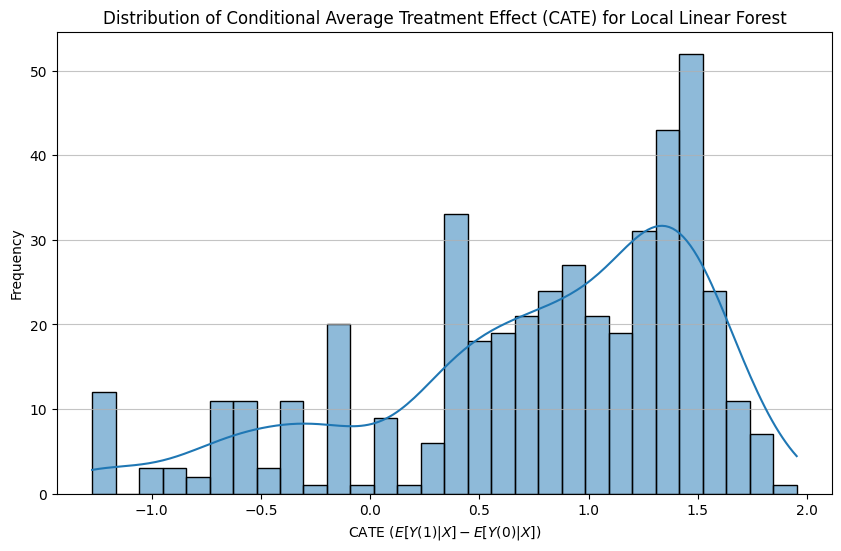

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(cate_llf, bins=30, kde=True)
plt.title('Distribution of Conditional Average Treatment Effect (CATE) for Local Linear Forest')
plt.xlabel('CATE ($E[Y(1)|X] - E[Y(0)|X]$)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

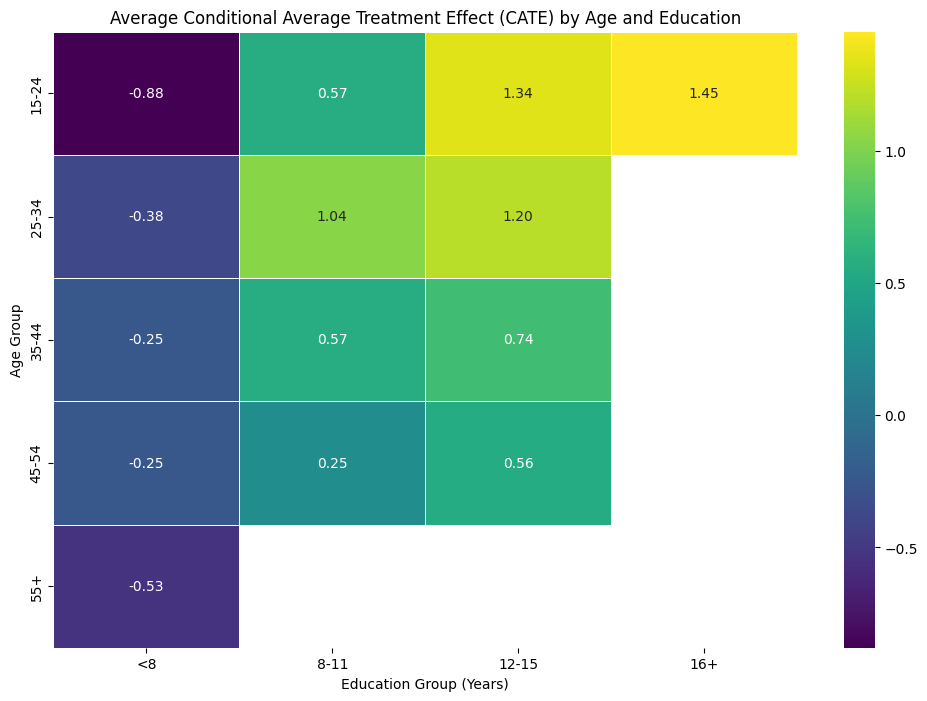

In [25]:
# Heatmap of CATE by age & education for the local linear forest

import matplotlib.pyplot as plt
import seaborn as sns

# Create a temporary DataFrame for CATE visualization
cate_df = df.copy()
cate_df['cate_llf'] = cate_llf

# Define bins for age and education to categorize them for the heatmap
age_bins = [15, 25, 35, 45, 55, 65]
age_labels = ['15-24', '25-34', '35-44', '45-54', '55+']
cate_df['age_group'] = pd.cut(cate_df['age'], bins=age_bins, labels=age_labels, right=False)

educ_bins = [0, 8, 12, 16, 20]
educ_labels = ['<8', '8-11', '12-15', '16+']
cate_df['educ_group'] = pd.cut(cate_df['educ'], bins=educ_bins, labels=educ_labels, right=False)

# Calculate the mean CATE for each age-education group
cate_heatmap_data = cate_df.groupby(['age_group', 'educ_group'])['cate_llf'].mean().unstack()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(cate_heatmap_data, annot=True, fmt=".2f", cmap="viridis", linewidths=.5)
plt.title('Average Conditional Average Treatment Effect (CATE) by Age and Education')
plt.xlabel('Education Group (Years)')
plt.ylabel('Age Group')
plt.show()


CATE Calibration Plot (Quantile Plot) for Local Linear Forest
This plot helps to visually inspect the quality of the CATE estimates. It compares the average estimated CATE within different quantiles of CATE estimates to the average observed treatment effect (estimated using Inverse Probability Weighting) within those same quantiles. For a perfectly calibrated CATE model, the points should lie along the 45-degree line (y=x).

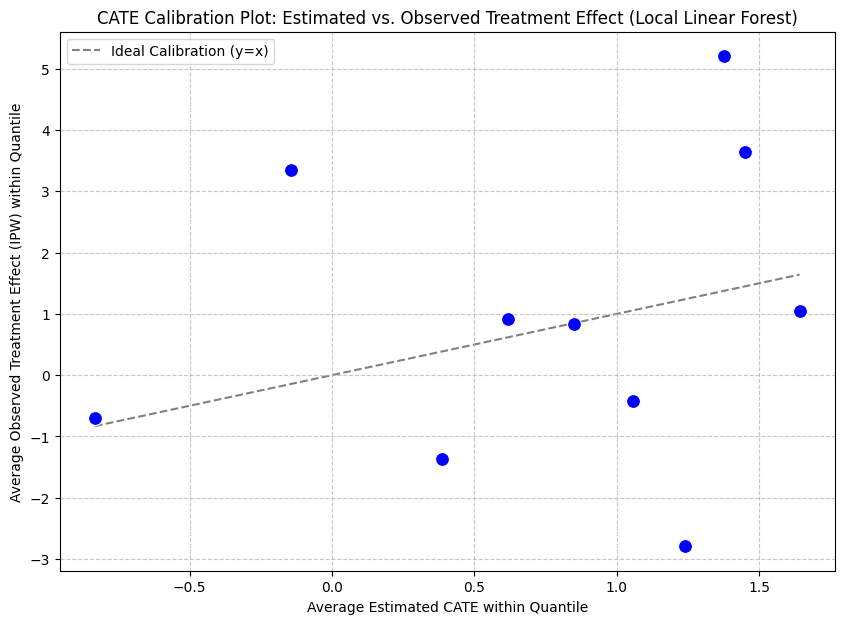

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for CATE analysis
cate_analysis_df = pd.DataFrame({
    'cate_llf': cate_llf,
    'y_oof': y_oof_rf_optimal,
    'T_oof': T_oof_rf_optimal,
    'p_scores_oof': p_scores_oof_rf_optimal
})

# Sort by CATE estimate and create 10 quantiles (bins)
cate_analysis_df = cate_analysis_df.sort_values(by='cate_llf').reset_index(drop=True)
cate_analysis_df['cate_bin'] = pd.qcut(cate_analysis_df['cate_llf'], q=10, labels=False, duplicates='drop')

# Calculate average estimated CATE and average observed treatment effect (IPW) for each bin
calibration_data = []
for bin_idx in sorted(cate_analysis_df['cate_bin'].unique()):
    subset = cate_analysis_df[cate_analysis_df['cate_bin'] == bin_idx]

    avg_estimated_cate = subset['cate_llf'].mean()

    # Calculate observed treatment effect for the bin using IPW
    # E[Y(1) - Y(0)] = E[Y*T/p - Y*(1-T)/(1-p)]
    ipw_term = (subset['y_oof'] * subset['T_oof'] / subset['p_scores_oof']) - \
               (subset['y_oof'] * (1 - subset['T_oof']) / (1 - subset['p_scores_oof']))

    avg_observed_effect = np.mean(ipw_term)

    calibration_data.append({
        'avg_estimated_cate': avg_estimated_cate,
        'avg_observed_effect': avg_observed_effect
    })

calibration_df = pd.DataFrame(calibration_data)

# Plot the calibration curve
plt.figure(figsize=(10, 7))
sns.scatterplot(x='avg_estimated_cate', y='avg_observed_effect', data=calibration_df, s=100, color='blue', zorder=5)
plt.plot([calibration_df['avg_estimated_cate'].min(), calibration_df['avg_estimated_cate'].max()],
         [calibration_df['avg_estimated_cate'].min(), calibration_df['avg_estimated_cate'].max()],
         '--', color='gray', label='Ideal Calibration (y=x)', zorder=1)
plt.title('CATE Calibration Plot: Estimated vs. Observed Treatment Effect (Local Linear Forest)')
plt.xlabel('Average Estimated CATE within Quantile')
plt.ylabel('Average Observed Treatment Effect (IPW) within Quantile')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

lol man sieht gar nix sinnvolles

In [27]:
#nochmal durchlesen: The calibration plot shows how well the estimated CATEs align with the actual observed treatment effects across different quantiles. Ideally, the points should fall along the gray dashed line (y=x). Let's analyze the deviations:

#Low CATE Quantiles (left side of the plot): For individuals with lower estimated CATEs, the observed treatment effect seems to be positive (around 0.53) for the lowest quantile, while the estimated CATE is negative (around -0.29). This suggests that the model might be underestimating the positive effect, or even predicting a negative effect, for some individuals who actually experience a benefit. Mid CATE Quantiles: In the middle ranges, there's significant variability. Some quantiles show the observed effect being lower than the estimated CATE (e.g., estimated CATE 0.25 vs observed -1.12; estimated CATE 0.50 vs observed -2.26). This indicates that for these groups, the model is overestimating the treatment effect, and in some cases, the observed effect is actually negative. High CATE Quantiles (right side of the plot): For individuals with higher estimated CATEs, we see observed effects that are generally positive and sometimes much higher than the estimated CATE (e.g., estimated CATE 1.21 vs observed 3.48; estimated CATE 1.37 vs observed 4.58). This suggests that for those predicted to benefit most, the model might be underestimating the magnitude of the positive effect. Overall, the plot indicates that while there's a general positive correlation between the estimated and observed effects, the model is not perfectly calibrated. There are clear deviations, suggesting that the model tends to both overestimate and underestimate the CATE in different quantiles. This could be due to several factors, including the complexity of the true underlying CATE function, limitations of the CausalForestDML model's ability to capture it, or residual confounding not fully accounted for by the covariates and the Double Machine Learning approach. This analysis highlights areas where the CATE estimation could be improved, perhaps by trying different base learners for model_y and model_t or by incorporating more relevant features

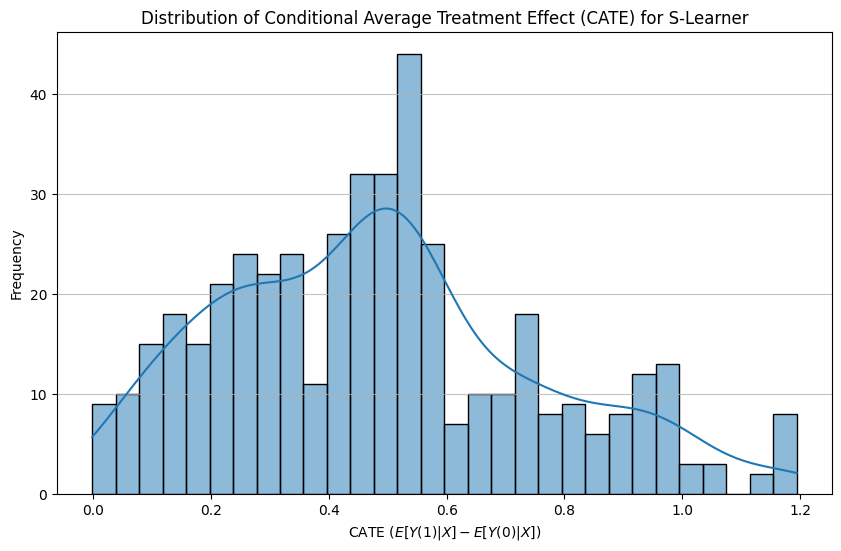

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(cate_s_learner, bins=30, kde=True)
plt.title('Distribution of Conditional Average Treatment Effect (CATE) for S-Learner')
plt.xlabel('CATE ($E[Y(1)|X] - E[Y(0)|X]$)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

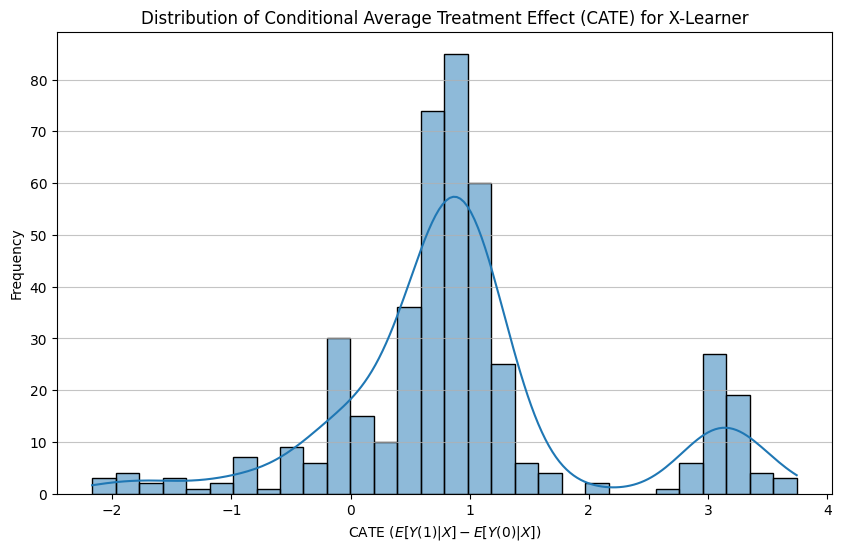

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(cate_x_learner, bins=30, kde=True)
plt.title('Distribution of Conditional Average Treatment Effect (CATE) for X-Learner')
plt.xlabel('CATE ($E[Y(1)|X] - E[Y(0)|X]$)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

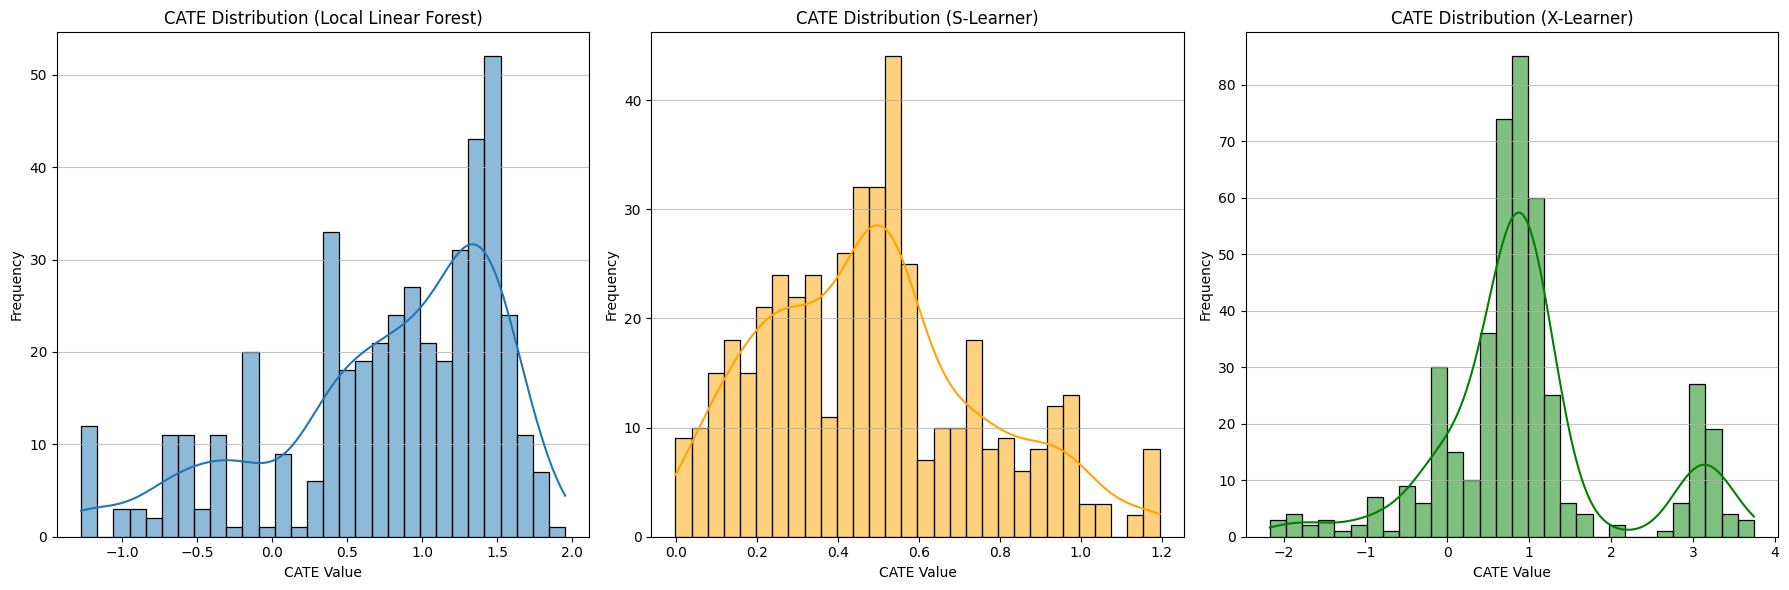

In [30]:
# comparison of CATE distributions

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 6))

# Plot for Local Linear Forest CATE
plt.subplot(1, 3, 1)
sns.histplot(cate_llf, bins=30, kde=True)
plt.title('CATE Distribution (Local Linear Forest)')
plt.xlabel('CATE Value')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

# Plot for S-Learner CATE
plt.subplot(1, 3, 2)
sns.histplot(cate_s_learner, bins=30, kde=True, color='orange')
plt.title('CATE Distribution (S-Learner)')
plt.xlabel('CATE Value')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

# Plot for X-Learner CATE
plt.subplot(1, 3, 3)
sns.histplot(cate_x_learner, bins=30, kde=True, color='green')
plt.title('CATE Distribution (X-Learner)')
plt.xlabel('CATE Value')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

## Evaluation Metrics

[Clearly specify which metrics you'll use to evaluate the model performance, and why you've chosen these metrics.]

look at quantile plots of ATE estimate by quantile/quartile of sorted CATE (plot AIPW ATE & sample ATE, see slide 25 of 4c lecture)


In [31]:
## Evaluate the model using your chosen metrics
# Example for classification
# y_pred = model.predict(X_test)
# print(classification_report(y_test, y_pred))

# Example for regression
# mse = mean_squared_error(y_test, y_pred)

# Your evaluation code here

#--> stack the models & calculate R-loss; or just MSE because we do not have confounding bias?
#or other loss function? (or is MSE loss already a nice loss function?)




In [32]:
# RMSE for CATE estimators

from sklearn.metrics import mean_squared_error

# As a benchmark, we use the individual ATE estimates from the optimal Random Forest
# (aipw_terms_rf_optimal), as it's a robust estimate for individual treatment effects
# and aligns with the base learners used for S-Learner and X-Learner.
reference_individual_ate = aipw_terms_rf_optimal

# Calculate RMSE for Local Linear Forest CATE
rmse_llf = np.sqrt(mean_squared_error(reference_individual_ate, cate_llf))
print(f"RMSE for Local Linear Forest CATE: {rmse_llf:.4f}")

# Calculate RMSE for S-Learner CATE
rmse_s_learner = np.sqrt(mean_squared_error(reference_individual_ate, cate_s_learner))
print(f"RMSE for S-Learner CATE: {rmse_s_learner:.4f}")

# Calculate RMSE for X-Learner CATE
rmse_x_learner = np.sqrt(mean_squared_error(reference_individual_ate, cate_x_learner))
print(f"RMSE for X-Learner CATE: {rmse_x_learner:.4f}")

# Calculate RMSE for Causal forest CATE
rmse_rf = np.sqrt(mean_squared_error(reference_individual_ate, cate_honest_cf))
print(f"RMSE for Causal forest CATE: {rmse_rf:.4f}")

RMSE for Local Linear Forest CATE: 8.1948
RMSE for S-Learner CATE: 8.1731
RMSE for X-Learner CATE: 8.1829
RMSE for Causal forest CATE: 8.1948


all of them are quite similar, but RSME would choose the S-learner

In [33]:
from sklearn.metrics import mean_squared_error

# Using aipw_terms_rf_optimal as the reference individual ATE
# This serves as our best estimate of the true individual treatment effect for comparison
reference_individual_ate_for_loss = aipw_terms_rf_optimal

print("Comparing CATE predictions using Mean Squared Error (R-loss):")

# Calculate MSE for Local Linear Forest CATE (cate_llf)
mse_llf = mean_squared_error(reference_individual_ate_for_loss, cate_llf)
print(f"MSE (R-loss) for Local Linear Forest CATE: {mse_llf:.4f}")

# Calculate MSE for S-Learner CATE (cate_s_learner)
mse_s_learner = mean_squared_error(reference_individual_ate_for_loss, cate_s_learner)
print(f"MSE (R-loss) for S-Learner CATE: {mse_s_learner:.4f}")

# Calculate MSE for X-Learner CATE (cate_x_learner)
mse_x_learner = mean_squared_error(reference_individual_ate_for_loss, cate_x_learner)
print(f"MSE (R-loss) for X-Learner CATE: {mse_x_learner:.4f}")

# Calculate MSE for Honest Causal Forest CATE (cate_honest_cf)
mse_honest_cf = mean_squared_error(reference_individual_ate_for_loss, cate_honest_cf)
print(f"MSE (R-loss) for Honest Causal Forest CATE: {mse_honest_cf:.4f}")


Comparing CATE predictions using Mean Squared Error (R-loss):
MSE (R-loss) for Local Linear Forest CATE: 67.1549
MSE (R-loss) for S-Learner CATE: 66.7996
MSE (R-loss) for X-Learner CATE: 66.9604
MSE (R-loss) for Honest Causal Forest CATE: 67.1549


would also choose the S-learner
# WHAT IS R-loss again??? & what is difference to MSE?

In [35]:
predicted_real_earnings_control = np.exp(m0_oof_rf_optimal)
predicted_real_earnings_treated = np.exp(m1_oof_rf_optimal)

# Calculate the difference in real earnings for each individual
individual_absolute_difference = predicted_real_earnings_treated - predicted_real_earnings_control

# Calculate the average of these individual absolute differences
average_absolute_treatment_effect = np.mean(individual_absolute_difference)

print(f"The Average Treatment Effect (ATE) in absolute money terms for Optimal RF is: ${average_absolute_treatment_effect:.2f}")

The Average Treatment Effect (ATE) in absolute money terms for Optimal RF is: $238.35


In [36]:
import numpy as np

# Prepare the input features for the overall model within the S-Learner.
# The overall_model expects an intercept term, the X_covariates, and the treatment variable.

# For the treated group (T=1)
# We need: 1 (intercept) + 6 (X_covariates) + 1 (treated T) = 8 features
X_treated_s_learner = np.hstack([np.ones((len(df), 1)), X_covariates, np.ones((len(df), 1))])
predicted_log_earnings_treated_s_learner = sl.overall_model.predict(X_treated_s_learner)

# For the control group (T=0)
# We need: 1 (intercept) + 6 (X_covariates) + 1 (control T) = 8 features
X_control_s_learner = np.hstack([np.ones((len(df), 1)), X_covariates, np.zeros((len(df), 1))])
predicted_log_earnings_control_s_learner = sl.overall_model.predict(X_control_s_learner)

# Exponentiate the predicted log outcomes and subtract 1 (due to the log(re78 + 1) transformation)
predicted_real_earnings_treated_s_learner = np.exp(predicted_log_earnings_treated_s_learner) - 1
predicted_real_earnings_control_s_learner = np.exp(predicted_log_earnings_control_s_learner) - 1

# Calculate the difference in real earnings for each individual
individual_absolute_difference_s_learner = predicted_real_earnings_treated_s_learner - predicted_real_earnings_control_s_learner

# Calculate the Average Treatment Effect (ATE) in absolute money terms
average_absolute_treatment_effect_s_learner = np.mean(individual_absolute_difference_s_learner)

print(f"The Average Treatment Effect (ATE) in absolute money terms for S-Learner is: ${average_absolute_treatment_effect_s_learner:.2f}")

The Average Treatment Effect (ATE) in absolute money terms for S-Learner is: $151.63


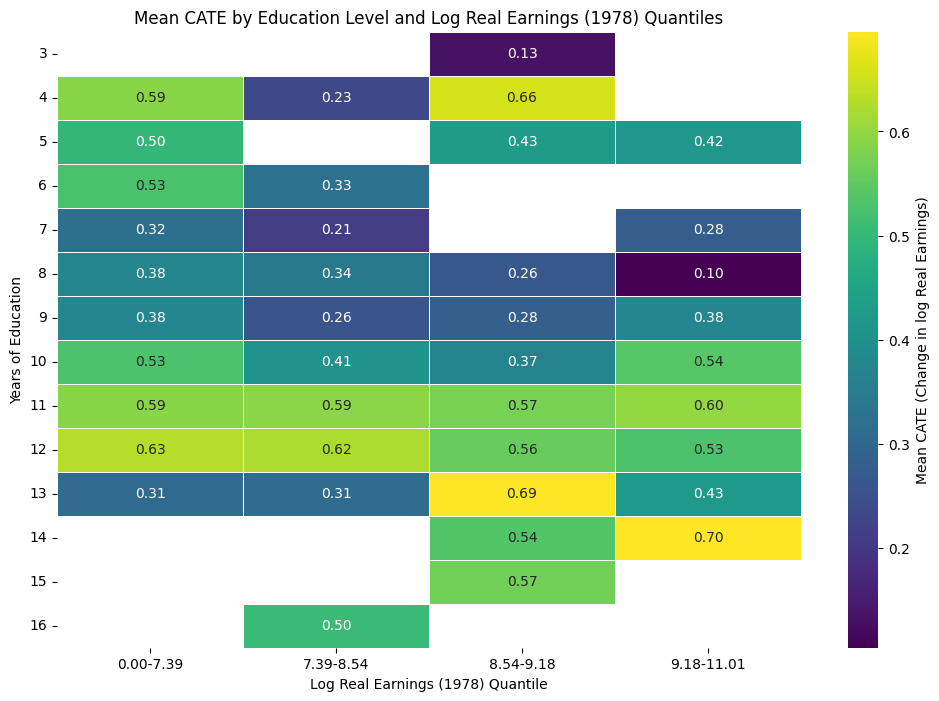

In [37]:
# Create a DataFrame for plotting, aligning CATE with 'educ' and 'lre78'
plot_df_full = pd.DataFrame({
    'CATE': cate_s_learner,
    'Education': df['educ'].values,
    'lre78': df['lre78'].values
})

# Bin lre78 into quantiles for a 2D heatmap
# Using qcut to create equal-sized bins based on quantiles
plot_df_full['lre78_bin'] = pd.qcut(plot_df_full['lre78'], q=5, labels=False, duplicates='drop')

# Map bin labels to more descriptive ranges for the heatmap
# Get the actual bin edges
_, bins = pd.qcut(df['lre78'], q=5, retbins=True, duplicates='drop')
bin_labels = [f'{bins[i]:.2f}-{bins[i+1]:.2f}' for i in range(len(bins)-1)]

# Handle cases where duplicates='drop' might reduce the number of bins
# and thus the number of labels needed.
if len(bin_labels) > len(plot_df_full['lre78_bin'].unique()):
    bin_labels = bin_labels[:len(plot_df_full['lre78_bin'].unique())]

plot_df_full['lre78_bin_label'] = plot_df_full['lre78_bin'].map(lambda x: bin_labels[x])

# Calculate the mean CATE for each combination of education level and lre78 bin
heatmap_data_2d = plot_df_full.groupby(['Education', 'lre78_bin_label'])['CATE'].mean().unstack()

# Reorder columns (lre78_bin_label) to be in ascending order of the numerical bins
# This is important if pd.qcut doesn't naturally sort them when converting to labels
# Extract the lower bound of each bin for sorting
sorted_columns = sorted(heatmap_data_2d.columns, key=lambda x: float(x.split('-')[0]))
heatmap_data_2d = heatmap_data_2d[sorted_columns]

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data_2d, annot=True, cmap='viridis', fmt=".2f", linewidths=.5,
            cbar_kws={'label': 'Mean CATE (Change in log Real Earnings)'})
plt.title('Mean CATE by Education Level and Log Real Earnings (1978) Quantiles')
plt.xlabel('Log Real Earnings (1978) Quantile')
plt.ylabel('Years of Education')
plt.yticks(rotation=0)
plt.show()

Finds higher positive treatment effects for those with 11 or 12 years of education for all quantiles of earnings in 1978.

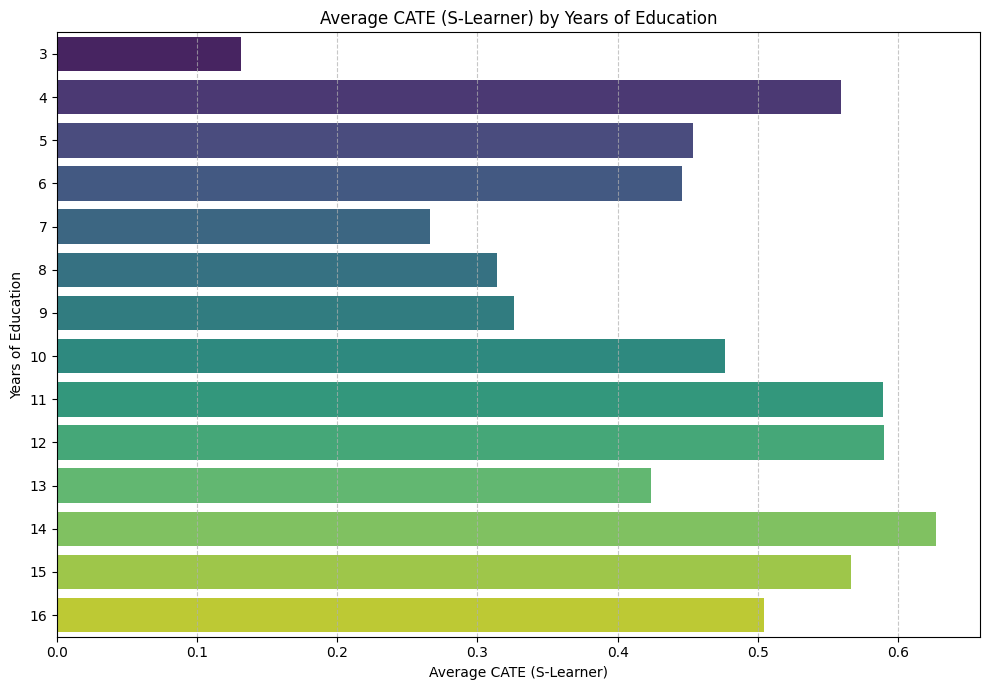

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a temporary DataFrame for CATE visualization, including education years
educ_cate_df = df.copy()
educ_cate_df['cate_s_learner'] = cate_s_learner

# Group by education and calculate the mean CATE for each education year
avg_cate_by_educ = educ_cate_df.groupby('educ')['cate_s_learner'].mean().reset_index()

# Sort by education for better visualization
avg_cate_by_educ = avg_cate_by_educ.sort_values(by='educ')

# Plot the CATE for each year of education
plt.figure(figsize=(10, 7))
sns.barplot(x='cate_s_learner', y='educ', data=avg_cate_by_educ, palette='viridis', orient='h')
plt.title('Average CATE (S-Learner) by Years of Education')
plt.xlabel('Average CATE (S-Learner)')
plt.ylabel('Years of Education')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Comparative Analysis

[Compare the performance of your model(s) against the baseline model. Discuss any improvements or setbacks and the reasons behind them.]


In [39]:
# Comparative Analysis code (if applicable)
# Example: comparing accuracy of the baseline model and the new model
# print(f"Baseline Model Accuracy: {baseline_accuracy}, New Model Accuracy: {new_model_accuracy}")


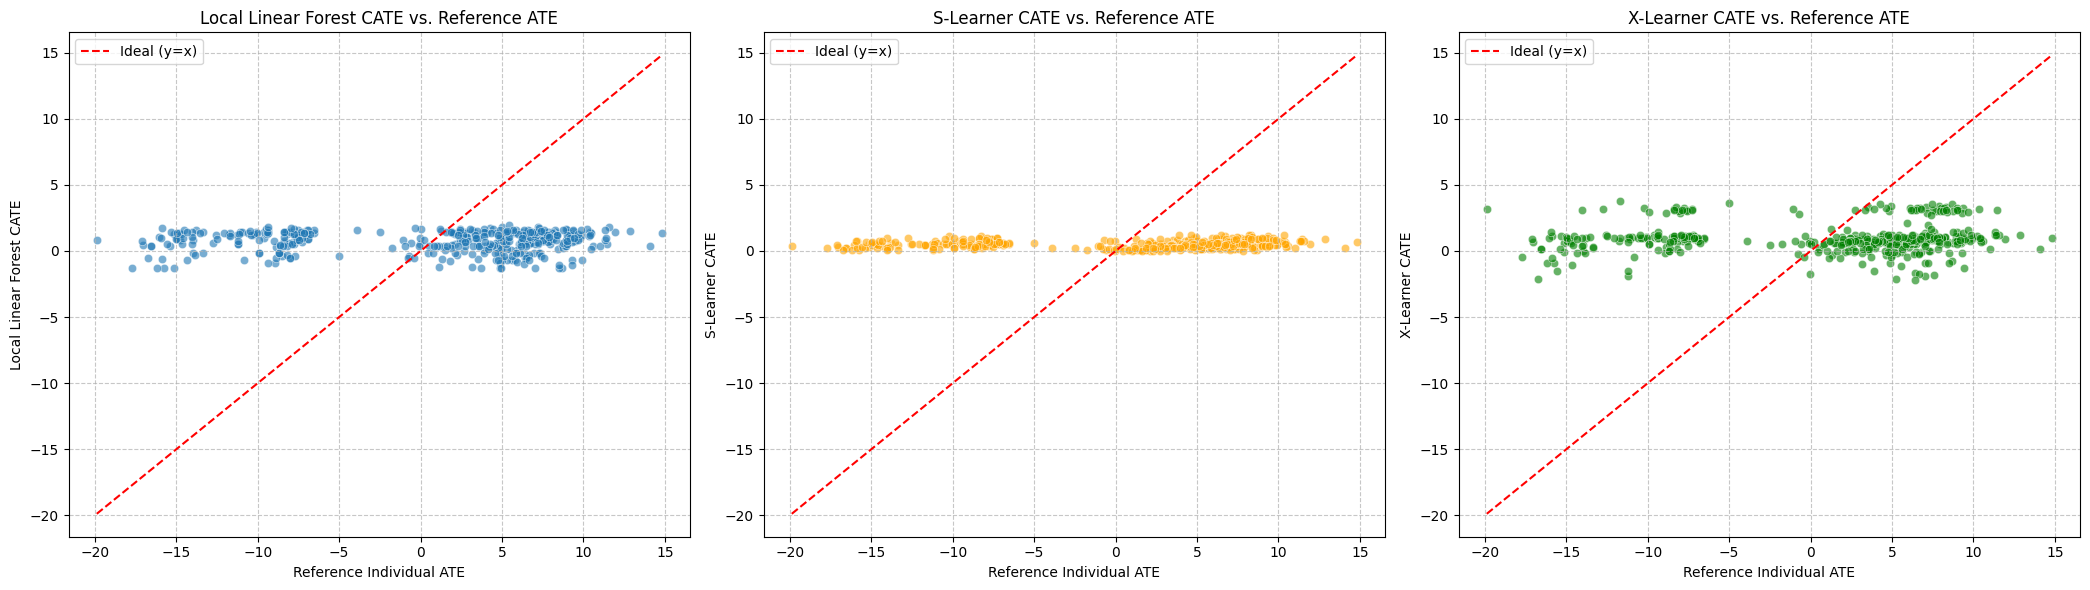

In [40]:
# forest CATEs vs. ATEs

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(21, 6))

# Plot for Local Linear Forest CATE vs. Reference ATE
plt.subplot(1, 3, 1)
sns.scatterplot(x=reference_individual_ate, y=cate_llf, alpha=0.6)
plt.plot([min(reference_individual_ate), max(reference_individual_ate)],
         [min(reference_individual_ate), max(reference_individual_ate)],
         '--r', label='Ideal (y=x)')
plt.title('Local Linear Forest CATE vs. Reference ATE')
plt.xlabel('Reference Individual ATE')
plt.ylabel('Local Linear Forest CATE')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Plot for S-Learner CATE vs. Reference ATE
plt.subplot(1, 3, 2)
sns.scatterplot(x=reference_individual_ate, y=cate_s_learner, alpha=0.6, color='orange')
plt.plot([min(reference_individual_ate), max(reference_individual_ate)],
         [min(reference_individual_ate), max(reference_individual_ate)],
         '--r', label='Ideal (y=x)')
plt.title('S-Learner CATE vs. Reference ATE')
plt.xlabel('Reference Individual ATE')
plt.ylabel('S-Learner CATE')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Plot for X-Learner CATE vs. Reference ATE
plt.subplot(1, 3, 3)
sns.scatterplot(x=reference_individual_ate, y=cate_x_learner, alpha=0.6, color='green')
plt.plot([min(reference_individual_ate), max(reference_individual_ate)],
         [min(reference_individual_ate), max(reference_individual_ate)],
         '--r', label='Ideal (y=x)')
plt.title('X-Learner CATE vs. Reference ATE')
plt.xlabel('Reference Individual ATE')
plt.ylabel('X-Learner CATE')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

This visualization compares the CATE estimates from each model against a robust benchmark of individual treatment effects (aipw_terms_rf_optimal). Points closer to the 45-degree line indicate better calibration and more accurate individual treatment effect predictions relative to the benchmark.

noch ausschreiben:

Points close to the red dashed line (y=x): Indicate that the model's CATE estimates are closely aligned with the reference individual ATE for those specific data points. This represents good calibration. Points above the red dashed line: Suggest that the model is overestimating the treatment effect compared to the reference ATE. For example, if a point has a reference ATE of 1 but a CATE estimate of 2, it would be above the line. Points below the red dashed line: Indicate that the model is underestimating the treatment effect compared to the reference ATE. For example, if a point has a reference ATE of 2 but a CATE estimate of 1, it would be below the line. Spread of points around the line: A wider spread suggests higher variability and less precise CATE estimation. A tighter cluster around the line indicates better model performance in predicting individual treatment effects.